# Autoencoders, Minimum Description Length and Helmholtz Free Energy — Summary

# https://www.cs.toronto.edu/~fritz/absps/cvq.pdf

## Abstract
The paper derives an objective function for training autoencoder networks grounded in the Minimum Description Length (MDL) principle. It shows that minimizing the total information needed to describe both the code vector and the reconstruction error leads naturally to a stochastic, Boltzmann-distributed choice of codes, where the generative weights define an energy function. Since computing the exact Boltzmann distribution over distributed codes is exponentially costly, the authors propose approximating it using the recognition weights of the autoencoder, yielding an upper bound on the true description length. This bound, formally equivalent to the Helmholtz free energy of statistical physics, is shown to serve as a Lyapunov function for learning, enabling autoencoders to discover non-linear, factorial codes.

## Problems
- Existing unsupervised learning methods (PCA and Vector Quantization) each capture only part of what is needed for good representation learning: PCA provides distributed, factorial codes but only linear mappings; VQ provides powerful non-linear mappings but only local (non-distributed) codes.
- There is no principled objective for training autoencoders to produce non-linear, distributed, factorial codes.
- Computing the exact posterior (Boltzmann) distribution over distributed code vectors is intractable because it requires summing over exponentially many possible codes.

## Proposed Solutions
- Apply the MDL communication-game framework to autoencoders: define a total description length composed of a code cost, a reconstruction cost, and a (ignored) model cost.
- Introduce the "bits-back" argument: exploiting stochasticity in code selection allows the sender to communicate additional random bits, reducing the effective expected cost. This yields the objective:
$$ F = \sum_i p_i E_i - H, \quad H = -\sum_i p_i \log p_i $$
- Show that $$F$$ has the exact form of Helmholtz free energy, minimized by the Boltzmann distribution:
$$ p_i = \frac{e^{-E_i}}{\sum_j e^{-E_j}} $$
- Since exact computation of this distribution over distributed codes is exponential, approximate it using the autoencoder's recognition weights, producing a tractable, factorial (independent-pool) suboptimal distribution. The resulting mismatch between true and approximate distributions manifests as a Kullback-Leibler penalty term, but the resulting F still upper-bounds the true description length and can be used as a Lyapunov function for gradient-based learning.
- Extend the single-code VQ case to Factorial Stochastic Vector Quantization (FVQ), where multiple independent pools ("VQs") each stochastically select one unit, and their combined activations reconstruct the input.

## Purpose
The central aim is to provide a rigorous, information-theoretic justification for training autoencoders to learn non-linear, factorial (distributed) representations, unifying PCA and VQ as special cases of a general MDL-based framework, and to make this learning computationally tractable despite the intractability of exact posterior inference in distributed generative models.

## Methodology
- **Theoretical derivation**: Starting from Shannon's coding theorem, the description length of an input vector is expressed as a Gaussian-coded reconstruction error plus a code cost, defined as the "energy" $$E_i$$ of a code (Eq. 1).
- **Bits-back communication game**: Derives the expected combined cost $$F$$ (Eq. 4) that accounts for recoverable random bits used in stochastic code selection.
- **Factorial VQ (FVQ) formulation**: Represents an input using $$d$$ independent pools ("VQs") of $$m$$ hidden units each, with reconstructed output:
$$ y_j = b_j + \sum_v \sum_i w_{ji}^v h_i^v $$
and reconstruction variance:
$$ V_j = \sum_v \sum_i h_i^v \left( w_{ji}^v - \sum_k w_{jk}^v h_k^v \right)^2 $$
- **Exact gradient computation**: Because output units are linear and errors are squared, the expected reconstruction cost and its derivatives with respect to network weights can be computed in closed form, avoiding slow/inaccurate Monte Carlo sampling of hidden unit pools.
- **Experimental setup**: A synthetic spline dataset of 200 images (8×12 pixels), each generated from 5 randomly positioned control points and blurred with a Gaussian, is used to test FVQ. A network with 4 VQs of 6 hidden units each is trained, and its performance is compared against (a) a single competing group of 24 stochastic hidden units, (b) four independent stochastic VQs each trained on separate vertical image slices, and (c) a purely linear PCA-style network with 24 hidden units.

## Results
- The factorial VQ network learns to represent each control-point segment height via one of its four VQ pools, allowing the four segments to be chained into an accurate reconstruction of the spline image.
- For new test images, FVQ achieves a description length of approximately 18 bits for reconstruction cost and 7 bits for code cost.
- A standard (non-factorial) stochastic VQ with 24 units in a single competing group performs substantially worse: 36 bits reconstruction cost and 4 bits code cost.
- Four independent stochastic VQs trained on separate image slices perform slightly worse than the factorial VQ (by about 5 bits), because they cannot smoothly blend segments across slice boundaries.
- A purely linear (PCA-like) network with 24 hidden units achieves slightly lower reconstruction cost but a much higher code cost overall.

## Conclusions
- The MDL/bits-back framework provides a principled derivation showing that Helmholtz free energy is the correct objective for training stochastic autoencoders, unifying PCA and VQ as limiting cases.
- Although computing the true posterior over distributed codes is generally intractable, using the recognition weights to approximate this posterior yields a tractable upper bound suitable as a Lyapunov function, with a KL-divergence penalty naturally encouraging the approximation to remain close to the true distribution.
- The factorial VQ experiments demonstrate that this approach enables autoencoders to discover meaningful, non-linear, factorial representations that outperform non-factorial stochastic VQ and slice-based independent VQs, while maintaining a more favorable code-cost/reconstruction-cost trade-off than purely linear PCA.
- The authors note broader applicability of the non-equilibrium Helmholtz free energy approach to more complex generative models, including population codes, and view it as generally useful for tractable gradient-based learning in models with many latent configurations.

# Mathematical and Statistical Content Summary

## 1. Coding Cost of a Real-Valued Component
**Concept:** Shannon's coding theorem applied to Gaussian-distributed data.
For a component coded with a Gaussian of mean zero and standard deviation $$\sigma$$, quantization width $$t$$:
$$ \text{cost}(x) = -\log t + 0.5 \log 2\pi\sigma^2 + \frac{x^2}{2\sigma^2} $$
**Role:** Establishes the baseline principle that communicating any value costs a number of bits related to how probable that value is under an assumed distribution — the foundation for defining "description length" throughout the paper.

## 2. Energy of a Code (Eq. 1)
$$ E_i = -\log \pi_i - k\log t + \frac{k}{2}\log 2\pi\sigma^2 + \frac{d_i^2}{2\sigma^2} $$
**Explanation:** This combines two costs into one number called "energy":
- $$-\log \pi_i$$: the cost of specifying which code (out of many) was used, based on its prior probability $$\pi_i$$.
- The remaining terms: the cost of encoding the reconstruction error $$d_i$$ (how far off the reconstruction is from the true input), assuming Gaussian noise with variance $$\sigma^2$$, over $$k$$ input dimensions.
**Role:** Defines a single scalar ("energy") per candidate code that captures the total description length if that code were chosen — analogous to physical energy in statistical mechanics.

## 3. Expected Cost Under Stochastic Code Selection (Eq. 2)
$$ \langle \text{Cost} \rangle = \sum_i p_i E_i $$
**Explanation:** If codes are picked stochastically with probability $$p_i$$ (instead of always choosing the lowest-energy code), the average cost is the probability-weighted sum of energies.
**Role:** Sets up the apparent paradox that choosing suboptimal codes stochastically seems to increase expected cost — motivating the "bits-back" argument that resolves this.

## 4. Entropy of the Code-Selection Distribution (Eq. 3)
$$ H = -\sum_i p_i \log p_i $$
**Explanation:** Standard Shannon entropy — measures the uncertainty (or "freedom of choice") in selecting a code.
**Role:** Represents the number of extra bits of information that can be smuggled into the message by exploiting randomness in the choice of code (the "bits-back" savings), since the receiver can later recover this randomness once it learns the full model.

## 5. Helmholtz Free Energy Objective (Eq. 4)
$$ F = \sum_i p_i E_i - H $$
**Explanation:** Combines expected energy and entropy into a single quantity, directly analogous to Helmholtz free energy in physics ($$F = \langle E \rangle - TS$$, with implicit temperature $$T=1$$).
**Role:** This is the paper's central objective function for training autoencoders. Minimizing $$F$$ balances two competing goals: pick low-energy (low-cost) codes, but retain enough randomness (entropy) to gain "bits back," since both terms trade off in the true expected description length.

## 6. Optimal (Boltzmann/Softmax) Distribution (Eq. 5)
$$ p_i = \frac{e^{-E_i}}{\sum_j e^{-E_j}} $$
**Explanation:** This is the probability distribution that minimizes $$F$$ for fixed energies $$E_i$$ — a Boltzmann distribution (equivalent to the softmax function in machine learning).
**Role:** Shows that the theoretically optimal way to stochastically select codes is exactly the posterior distribution of a mixture-of-Gaussians model, linking MDL-based autoencoder training to well-known probabilistic clustering. This distribution is expensive to compute exactly when codes are distributed (exponentially many combinations), motivating an approximation.

## 7. Expected Reconstructed Output (Eq. 6)
$$ y_j = b_j + \sum_v \sum_i w_{ji}^v h_i^v $$
**Explanation:** For "Factorial Vector Quantization" (multiple independent pools of units, or "VQs"), the expected output at unit $$j$$ is a weighted sum over all pools $$v$$ and hidden units $$i$$, where $$h_i^v$$ is the probability of selecting unit $$i$$ in pool $$v$$, and $$w_{ji}^v$$ is the generative weight from that unit to output $$j$$, plus a bias $$b_j$$.
**Role:** Gives a closed-form (non-sampling) way to compute the network's expected output under the stochastic factorial code, enabling exact rather than noisy Monte Carlo estimates.

## 8. Variance of Reconstructed Output (Eq. 7)
$$ V_j = \sum_v \sum_i h_i^v \left( w_{ji}^v - \sum_k w_{jk}^v h_k^v \right)^2 $$
**Explanation:** Computes how much the reconstructed output $$y_j$$ varies due to the randomness of code selection within each pool, assuming independence across pools (factorial assumption). Each term measures the squared deviation of each unit's weight from the pool's expected weighted contribution, scaled by that unit's selection probability.
**Role:** Combined with Eq. 6, allows exact computation of the expected squared reconstruction error, $$V_j + (y_j - d_j)^2$$ (where $$d_j$$ is the desired/target output), which is needed to compute the reconstruction cost term in $$F$$ and its gradients — making the entire objective differentiable and tractable for gradient descent, without requiring stochastic sampling.

## 9. Kullback–Leibler Divergence (Implicit)
**Concept:** Although not explicitly written as an equation, the paper states that using a suboptimal (factorial) distribution instead of the true posterior introduces an excess cost equal to a KL-divergence term between the approximate and true distributions.
**Role:** Explains why using the tractable factorial approximation still gives a valid upper bound on the true description length — the KL term is always non-negative, so $$F$$ computed with the approximation over-estimates (never under-estimates) the true cost, making it safe to use as a Lyapunov function for learning.

## Summary Table

| Equation | Concept | Role in Paper |
|---|---|---|
| Gaussian coding cost | Bit-cost of real values | Basis for defining description length |
| Eq. 1 ($$E_i$$) | Energy of a code | Combines code cost + reconstruction cost |
| Eq. 2 ($$\langle \text{Cost}\rangle$$) | Expected cost | Naive expected cost under stochastic coding |
| Eq. 3 ($$H$$) | Entropy | Bits recoverable via "bits-back" argument |
| Eq. 4 ($$F$$) | Helmholtz free energy | Main training objective (Lyapunov function) |
| Eq. 5 ($$p_i$$) | Boltzmann/softmax distribution | Optimal code-selection distribution minimizing $$F$$ |
| Eq. 6 ($$y_j$$) | Expected output | Exact computation of reconstruction under factorial codes |
| Eq. 7 ($$V_j$$) | Output variance | Enables exact (non-sampled) reconstruction cost and gradients |
| KL divergence (implicit) | Approximation gap | Justifies using tractable suboptimal distributions as valid bounds |

# Key Problems, Limitations of Prior Work, and Proposed Solutions

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | PCA produces distributed, factorial codes but is restricted to linear mappings between input and code | Cannot capture non-linear structure in data; representational power is limited to linear subspaces | Frame autoencoder training under an MDL objective that permits non-linear recognition/generative mappings while still encouraging factorial (distributed) codes |
| 2 | Vector Quantization (VQ) supports powerful non-linear mappings but yields only local (non-distributed) codes | Cannot represent data efficiently when multiple independent underlying factors must be combined; representational capacity scales poorly with complexity | Introduce Factorial Vector Quantization (FVQ), where several independent VQ pools jointly and non-linearly reconstruct the input, combining non-linearity with distributed coding |
| 3 | No principled, unified objective function exists for training autoencoders to discover non-linear, factorial representations | Prior methods (PCA, VQ) are treated as separate special-case algorithms rather than instances of one general framework, limiting theoretical grounding and extensibility | Derive an objective from the Minimum Description Length (MDL) principle that unifies PCA and VQ as special cases and generalizes to non-linear factorial autoencoders |
| 4 | Standard (deterministic) VQ wastes the information value of having multiple equally good codes for the same input | Deterministic code selection cannot exploit redundancy among equally good codes, resulting in an unnecessarily high effective description length | Introduce the "bits-back" argument: stochastically select codes according to a Boltzmann distribution, allowing the entropy of the choice to be recovered as bits communicated "for free" |
| 5 | Computing the exact posterior (Boltzmann) distribution over distributed codes requires summing over exponentially many possible code combinations | Makes exact maximum-likelihood learning intractable for any generative model using distributed hidden representations | Approximate the true posterior using the autoencoder's recognition weights, restricting to a tractable factorial (independent-pool) distribution |
| 6 | Approximating the posterior with a suboptimal (factorial) distribution risks compromising the validity of the learning objective | Without theoretical guarantees, such approximations could produce inconsistent or non-convergent learning dynamics | Show that the resulting Helmholtz free energy $$F$$ is always an upper bound on the true description length (excess cost equals a KL divergence term), so $$F$$ remains a valid Lyapunov function for learning despite the approximation |
| 7 | Computing gradients of the expected reconstruction cost via Monte Carlo sampling of stochastic hidden units is slow and/or inaccurate | Impedes efficient, stable gradient-based training of stochastic distributed-code models | Derive closed-form expressions for expected reconstructed output and its variance (Eqs. 6–7), enabling exact, non-sampled computation of reconstruction cost and its derivatives for linear output units with squared-error loss |

In [1]:
# !pip -q install datasets scikit-learn

# =====================================================================================
# Educational Replication: "Autoencoders, Minimum Description Length and Helmholtz
# Free Energy" (Hinton & Zemel, 2001) — Factorial Stochastic Vector Quantization
# adapted to CIFAR-10.
#
# WHAT THIS CODE DOES (beginner-friendly overview):
#   - An "autoencoder" here has two halves:
#       * The RECOGNITION network looks at an image and guesses a CODE for it.
#       * The GENERATIVE network takes that code and tries to rebuild the image.
#   - Instead of one ordinary bottleneck vector, the code is split into several
#     independent "pools" (like independent dials), and each pool must choose ONE
#     of a few discrete alternatives ("categorical" choice). This is a DISTRIBUTED
#     code: information about the image is spread across multiple pools at once.
#   - Because each pool can pick 6 alternatives and there are 4 pools, there are
#     6^4 = 1296 possible combined codes. We NEVER enumerate all of them — that
#     would be intractable for larger pools/pool counts. Instead we use a
#     FACTORIAL approximation: we treat the pools as independent of each other,
#     so we only need to describe a probability distribution over 6 alternatives,
#     four times, instead of over 1296 joint combinations.
#   - Training does NOT minimize plain reconstruction error. Following the paper's
#     Minimum Description Length (MDL) idea, we minimize a "free energy":
#         F = reconstruction_cost + code_cost - entropy
#     - reconstruction_cost: bits needed to fix up the residual error.
#     - code_cost: bits needed to specify which code alternative was picked,
#       assuming some prior probability over alternatives.
#     - entropy: when the recognition network is unsure/spreads its probability
#       across several equally-good alternatives, the paper shows (the
#       "bits-back" argument) that this uncertainty can be exploited to smuggle
#       extra information for free — so entropy is SUBTRACTED from the cost.
#   - This total F is mathematically the same form as Helmholtz free energy in
#     physics (expected energy minus entropy), and it forms an UPPER BOUND on the
#     true, intractable description length — so minimizing it is a safe,
#     tractable stand-in (a "Lyapunov function") for the true objective.
#   - Because true categorical sampling is not differentiable, we use the
#     Gumbel-Softmax trick (a modern trick unavailable to the 2001 authors) to
#     get a discrete-like sample that we can still backpropagate through.
#   - Labels are NEVER used during this unsupervised training. After training we
#     freeze everything and train a simple linear classifier ("linear probe") on
#     the learned codes, purely to check how much class information ended up in
#     the representation. This differs from a deterministic autoencoder (no
#     stochasticity/entropy term), a VAE (continuous Gaussian latents + KL to a
#     fixed prior), and a VQ-VAE (hard nearest-neighbor codebook lookup + a
#     commitment loss) — none of which match the paper's specific factorial,
#     entropy-aware, bits-back formulation.
# =====================================================================================

import os
import io
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F_nn
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from PIL import Image
from IPython.display import display, Image as IPImage

from datasets import load_dataset

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

import torchvision.transforms as T

In [2]:
# ---------------------------------------------------------------------------------
# 0. GLOBAL WHITE VISUAL THEME (enforced now, and again before the final dashboard)
# ---------------------------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "0.85",
        "axes.grid": False,
    })

set_white_theme()

In [3]:
# ---------------------------------------------------------------------------------
# 1. REPRODUCIBILITY & DEVICE
# ---------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ---------------------------------------------------------------------------------
# 2. DATASET — HuggingFace CIFAR-10 ONLY
# ---------------------------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class HFCifar10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""

    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(item["label"])
        return img_tensor, label


full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

# Small subsets to keep this educational demo computationally manageable.
train_dataset = Subset(full_train_dataset, list(range(2000)))
test_dataset = Subset(full_test_dataset, list(range(400)))

pin_mem = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=pin_mem
)
eval_train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=pin_mem
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=pin_mem
)

In [5]:
# ---------------------------------------------------------------------------------
# 3. INPUT REPRESENTATION: pool 64x64 images down to 16x16, flatten to 768-dim
# ---------------------------------------------------------------------------------
INPUT_H, INPUT_W = 16, 16
INPUT_DIM = 3 * INPUT_H * INPUT_W  # 768

IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
IMAGENET_STD_T = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)


def make_pooled_targets(images_normalized):
    """
    Takes normalized [B, 3, 64, 64] images (as produced by the DataLoader) and
    produces a BOUNDED reconstruction target in [0, 1], suitable for a sigmoid
    decoder:
        1. Adaptive-average-pool to 16x16 (keeps computation manageable).
        2. Un-normalize (undo the ImageNet mean/std) back to raw pixel range.
        3. Clamp to [0, 1] to guarantee a valid target range.
        4. Flatten to [B, 768].
    """
    pooled = F_nn.adaptive_avg_pool2d(images_normalized, (INPUT_H, INPUT_W))
    mean = IMAGENET_MEAN_T.to(pooled.device)
    std = IMAGENET_STD_T.to(pooled.device)
    unnormalized = pooled * std + mean
    clamped = torch.clamp(unnormalized, 0.0, 1.0)
    flattened = clamped.view(clamped.size(0), -1)
    return pooled, flattened

In [6]:
# ---------------------------------------------------------------------------------
# 4. FACTORIAL CODE HYPERPARAMETERS
# ---------------------------------------------------------------------------------
NUM_POOLS = 4          # number of independent discrete latent factors ("VQs")
UNITS_PER_POOL = 6     # alternatives available within each pool
NUM_POSSIBLE_CODES = UNITS_PER_POOL ** NUM_POOLS  # 6^4 = 1296, never enumerated

EPSILON = 1e-8

In [7]:
# ---------------------------------------------------------------------------------
# 5. RECOGNITION NETWORK  q(h | x)  — factorial approximate posterior
# ---------------------------------------------------------------------------------
class RecognitionNetwork(nn.Module):
    """
    Maps a flattened image (768-dim) to logits over NUM_POOLS independent
    categorical pools, each with UNITS_PER_POOL alternatives.

    Because we apply softmax SEPARATELY within each pool (not jointly over all
    combinations), the resulting distribution factorizes:
        q(h | x) = product_v q(h_v | x)
    This is exactly the paper's tractable "suboptimal" factorial approximation
    to the true (exponentially expensive) posterior over the full joint code.
    """

    def __init__(self, input_dim, num_pools, units_per_pool, hidden_dim=256):
        super().__init__()
        self.num_pools = num_pools
        self.units_per_pool = units_per_pool
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, num_pools * units_per_pool),
        )

    def forward(self, x):
        logits = self.net(x)
        logits = logits.view(-1, self.num_pools, self.units_per_pool)
        return logits  # [B, NUM_POOLS, UNITS_PER_POOL]

In [8]:
# ---------------------------------------------------------------------------------
# 6. GENERATIVE MODEL — explicit additive codebook weights
# ---------------------------------------------------------------------------------
class GenerativeCodebook(nn.Module):
    """
    Stores one reconstruction "contribution" vector per (pool, unit). A selected
    code (one-hot per pool) contributes additively to the reconstruction, mirroring
    Eq. 6 of the paper: y_j = b_j + sum_v sum_i w_ji^v * h_i^v.
    """

    def __init__(self, num_pools, units_per_pool, input_dim):
        super().__init__()
        self.num_pools = num_pools
        self.units_per_pool = units_per_pool
        self.input_dim = input_dim
        # generative_weights[v, i, :] is the additive contribution of unit i in pool v
        self.generative_weights = nn.Parameter(
            0.01 * torch.randn(num_pools, units_per_pool, input_dim)
        )
        self.generative_bias = nn.Parameter(torch.zeros(input_dim))

    def forward(self, z):
        """
        z: [B, NUM_POOLS, UNITS_PER_POOL] one-hot (or soft) code assignments.
        Returns reconstruction_logits (pre-sigmoid): [B, INPUT_DIM]
        """
        # einsum: for each sample, sum over pools & units of z[v,i] * W[v,i,:]
        contribution = torch.einsum("bvi,vid->bd", z, self.generative_weights)
        reconstruction_logits = self.generative_bias.unsqueeze(0) + contribution
        return reconstruction_logits

In [9]:
# ---------------------------------------------------------------------------------
# 7. FULL MODEL WRAPPER
# ---------------------------------------------------------------------------------
class FactorialVQAutoencoder(nn.Module):
    def __init__(self, input_dim, num_pools, units_per_pool, hidden_dim=256):
        super().__init__()
        self.recognition = RecognitionNetwork(input_dim, num_pools, units_per_pool, hidden_dim)
        self.generative = GenerativeCodebook(num_pools, units_per_pool, input_dim)
        self.num_pools = num_pools
        self.units_per_pool = units_per_pool
        self.input_dim = input_dim

    def forward(self, x, temperature=1.0, hard=True):
        recognition_logits = self.recognition(x)  # [B, V, U]

        # Soft (ordinary) factorial probabilities — used for entropy, code cost,
        # and expected reconstruction statistics (NOT just for visualization).
        recognition_probabilities = F_nn.softmax(recognition_logits, dim=-1)

        # Differentiable discrete-like sample via straight-through Gumbel-Softmax.
        # Forward pass: a hard one-hot code per pool (mimics true stochastic
        # categorical selection). Backward pass: gradients flow through the soft
        # probabilities. This is a modern educational stand-in for the paper's
        # exact stochastic code sampling.
        sampled_code = F_nn.gumbel_softmax(
            recognition_logits, tau=temperature, hard=hard, dim=-1
        )  # [B, V, U]

        sampled_reconstruction_logits = self.generative(sampled_code)
        sampled_reconstruction = torch.sigmoid(sampled_reconstruction_logits)

        return {
            "recognition_logits": recognition_logits,
            "recognition_probabilities": recognition_probabilities,
            "sampled_code": sampled_code,
            "sampled_reconstruction": sampled_reconstruction,
        }

    def expected_reconstruction_stats(self, recognition_probabilities, variance_weight=1.0):
        """
        Implements the paper's exact-expectation idea (Eqs. 6-7) for LINEAR
        generative outputs under a factorial categorical distribution:

            mean_logits = bias + sum_v sum_i q[v,i] * W[v,i,:]
            pool_variance = sum_i q[v,i]*W[v,i,:]^2 - (sum_i q[v,i]*W[v,i,:])^2
            total_variance = sum_v pool_variance

        NOTE: The original paper derives this exactly for LINEAR output units.
        Here we apply a sigmoid nonlinearity to keep reconstructions bounded in
        [0, 1], which means this expected-value / variance computation is an
        APPROXIMATION (computed in the pre-sigmoid / logit space), not an exact
        closed form for the sigmoid outputs themselves.
        """
        W = self.generative.generative_weights  # [V, U, D]
        bias = self.generative.generative_bias  # [D]

        # mean_logits: [B, D]
        mean_logits = bias.unsqueeze(0) + torch.einsum("bvi,vid->bd", recognition_probabilities, W)
        mean_reconstruction = torch.sigmoid(mean_logits)

        # Per-pool second moment and mean-squared, in logit/contribution space.
        W_sq = W ** 2  # [V, U, D]
        pool_second_moment = torch.einsum("bvi,vid->bvd", recognition_probabilities, W_sq)  # [B, V, D]
        pool_mean = torch.einsum("bvi,vid->bvd", recognition_probabilities, W)  # [B, V, D]
        pool_mean_squared = pool_mean ** 2
        pool_variance = pool_second_moment - pool_mean_squared
        pool_variance = torch.clamp(pool_variance, min=0.0)  # guard tiny negative noise
        total_variance = pool_variance.sum(dim=1)  # sum over pools -> [B, D]

        return mean_reconstruction, total_variance


model = FactorialVQAutoencoder(INPUT_DIM, NUM_POOLS, UNITS_PER_POOL, hidden_dim=256).to(device)

In [10]:
# ---------------------------------------------------------------------------------
# 8. MDL / HELMHOLTZ FREE-ENERGY OBJECTIVE
# ---------------------------------------------------------------------------------
PRIOR_PROBABILITY = 1.0 / UNITS_PER_POOL  # uniform prior over alternatives per pool

RECONSTRUCTION_WEIGHT = 1.0
CODE_WEIGHT = 0.01
ENTROPY_WEIGHT = 0.01
VARIANCE_WEIGHT = 0.5


def compute_free_energy(model, target, recognition_probabilities, mean_reconstruction,
                         total_variance, sampled_reconstruction):
    """
    Combines three terms into the paper-inspired free-energy objective:

        F = recon_weight * reconstruction_cost
            + code_weight * code_cost
            - entropy_weight * entropy

    - reconstruction_cost: expected squared error between the EXPECTED
      reconstruction (mean_reconstruction) and the target, plus a variance
      penalty term (uncertainty contributed by stochastic code choices).
    - code_cost: expected bits needed to specify which alternative was picked
      in each pool, under a fixed (uniform) prior over alternatives.
    - entropy: recognition-distribution entropy; SUBTRACTED because, per the
      paper's "bits-back" argument, uncertainty in code choice can be used to
      communicate extra information for free, reducing the true expected cost.

    This is explicitly NOT a classification loss, NOT a VAE KL term, and NOT a
    VQ-VAE commitment loss — it is a from-scratch MDL/free-energy formulation.
    """
    # A. Expected reconstruction cost (uses mean_reconstruction + variance term)
    squared_error = (mean_reconstruction - target) ** 2
    reconstruction_cost = (squared_error + VARIANCE_WEIGHT * total_variance).sum(dim=1).mean()

    # B. Code cost: -log(prior) weighted by recognition probability, summed over
    #    pools & units (expected number of bits to specify the chosen alternative).
    neg_log_prior = -math.log(PRIOR_PROBABILITY + EPSILON)
    code_cost = (recognition_probabilities * neg_log_prior).sum(dim=(1, 2)).mean()

    # C. Recognition-distribution entropy (bits-back saving)
    entropy = -(recognition_probabilities * torch.log(recognition_probabilities + EPSILON)).sum(dim=(1, 2)).mean()

    free_energy = (
        RECONSTRUCTION_WEIGHT * reconstruction_cost
        + CODE_WEIGHT * code_cost
        - ENTROPY_WEIGHT * entropy
    )

    # Also compute a plain sampled-reconstruction MSE purely as a diagnostic metric
    # (NOT used in the optimized objective).
    sampled_mse = ((sampled_reconstruction - target) ** 2).sum(dim=1).mean()
    expected_mse = squared_error.sum(dim=1).mean()

    return {
        "free_energy": free_energy,
        "reconstruction_cost": reconstruction_cost,
        "code_cost": code_cost,
        "entropy": entropy,
        "mean_variance": total_variance.mean(),
        "sampled_mse": sampled_mse,
        "expected_mse": expected_mse,
    }

In [11]:
# ---------------------------------------------------------------------------------
# 9. DATA SANITY CHECK
# ---------------------------------------------------------------------------------
print("\n===== DATA SANITY CHECK =====")
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

pooled_imgs, recon_targets = make_pooled_targets(sample_images)

model.eval()
with torch.no_grad():
    out = model(recon_targets, temperature=1.0, hard=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Original image-batch shape: {tuple(sample_images.shape)}")
print(f"Pooled image shape: {tuple(pooled_imgs.shape)}")
print(f"Flattened reconstruction-target shape: {tuple(recon_targets.shape)}")
print(f"Label range: [{sample_labels.min().item()}, {sample_labels.max().item()}]")
print(f"First eight integer labels: {sample_labels[:8].tolist()}")
print(f"First eight class names: {[class_names[l] for l in sample_labels[:8].tolist()]}")
print(f"Recognition-logit shape: {tuple(out['recognition_logits'].shape)}")
print(f"Recognition-probability shape: {tuple(out['recognition_probabilities'].shape)}")
print(f"Sampled-code shape: {tuple(out['sampled_code'].shape)}")
print(f"Reconstruction shape: {tuple(out['sampled_reconstruction'].shape)}")
print(f"Number of possible distributed codes (6^4): {NUM_POSSIBLE_CODES}")

assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9, "Labels out of range"
assert recon_targets.min().item() >= -1e-5 and recon_targets.max().item() <= 1.0 + 1e-5, "Targets out of [0,1]"
pool_sums = out["recognition_probabilities"].sum(dim=-1)
assert torch.allclose(pool_sums, torch.ones_like(pool_sums), atol=1e-3), "Pool probabilities don't sum to 1"
hard_sums = out["sampled_code"].sum(dim=-1)
assert torch.allclose(hard_sums, torch.ones_like(hard_sums), atol=1e-3), "Hard code isn't one-hot per pool"
assert torch.isfinite(out["recognition_logits"]).all(), "Non-finite recognition logits"
assert out["sampled_reconstruction"].min().item() >= 0.0 and out["sampled_reconstruction"].max().item() <= 1.0, \
    "Reconstruction outside [0,1]"
print("All sanity checks passed.\n")

model.train()


===== DATA SANITY CHECK =====
Number of training samples: 2000
Number of test samples: 400
Original image-batch shape: (64, 3, 64, 64)
Pooled image shape: (64, 3, 16, 16)
Flattened reconstruction-target shape: (64, 768)
Label range: [0, 9]
First eight integer labels: [1, 9, 2, 6, 4, 2, 6, 9]
First eight class names: ['automobile', 'truck', 'bird', 'frog', 'deer', 'bird', 'frog', 'truck']
Recognition-logit shape: (64, 4, 6)
Recognition-probability shape: (64, 4, 6)
Sampled-code shape: (64, 4, 6)
Reconstruction shape: (64, 768)
Number of possible distributed codes (6^4): 1296
All sanity checks passed.



FactorialVQAutoencoder(
  (recognition): RecognitionNetwork(
    (net): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): Sigmoid()
      (2): Linear(in_features=256, out_features=24, bias=True)
    )
  )
  (generative): GenerativeCodebook()
)

In [12]:
# ---------------------------------------------------------------------------------
# 10. OPTIMIZATION SETUP
# ---------------------------------------------------------------------------------
EPOCHS = 5
LEARNING_RATE = 1e-3
TEMPERATURE_SCHEDULE = [1.0, 0.9, 0.8, 0.7, 0.6]

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_free_energy": [], "val_free_energy": [],
    "train_recon_cost": [], "val_recon_cost": [],
    "train_code_cost": [], "val_code_cost": [],
    "train_entropy": [], "val_entropy": [],
    "train_variance": [], "val_variance": [],
    "train_sampled_mse": [], "val_sampled_mse": [],
    "train_expected_mse": [], "val_expected_mse": [],
    "pool_entropy_per_epoch": [],       # list of arrays, shape [NUM_POOLS]
    "effective_units_per_epoch": [],    # list of arrays, shape [NUM_POOLS]
}

In [13]:
# ---------------------------------------------------------------------------------
# 11. DIAGNOSTIC HELPERS (factoriality / pool usage) — informational only,
#     NOT added to the training objective.
# ---------------------------------------------------------------------------------
def compute_pool_diagnostics(all_probabilities):
    """
    all_probabilities: [N, NUM_POOLS, UNITS_PER_POOL] (numpy array)
    Returns:
      - mean_entropy_per_pool: [NUM_POOLS]
      - mean_usage_per_pool: [NUM_POOLS, UNITS_PER_POOL]
      - effective_units_per_pool: [NUM_POOLS]  (exp of entropy of AVERAGE usage)
      - mutual_info_matrix: [NUM_POOLS, NUM_POOLS] (based on hard assignments)
      - correlation_matrix: [NUM_POOLS, NUM_POOLS] (based on flattened soft probs)
    """
    eps = 1e-8
    per_sample_entropy = -np.sum(all_probabilities * np.log(all_probabilities + eps), axis=-1)  # [N, V]
    mean_entropy_per_pool = per_sample_entropy.mean(axis=0)  # [V]

    mean_usage_per_pool = all_probabilities.mean(axis=0)  # [V, U]
    avg_entropy = -np.sum(mean_usage_per_pool * np.log(mean_usage_per_pool + eps), axis=-1)  # [V]
    effective_units_per_pool = np.exp(avg_entropy)

    hard_assignments = np.argmax(all_probabilities, axis=-1)  # [N, V]
    V = all_probabilities.shape[1]
    mutual_info_matrix = np.zeros((V, V))
    for a in range(V):
        for b in range(V):
            if a == b:
                mutual_info_matrix[a, b] = mean_entropy_per_pool[a]
                continue
            joint = {}
            for n in range(hard_assignments.shape[0]):
                key = (hard_assignments[n, a], hard_assignments[n, b])
                joint[key] = joint.get(key, 0) + 1
            total = hard_assignments.shape[0]
            mi = 0.0
            marg_a = {}
            marg_b = {}
            for (ka, kb), cnt in joint.items():
                marg_a[ka] = marg_a.get(ka, 0) + cnt
                marg_b[kb] = marg_b.get(kb, 0) + cnt
            for (ka, kb), cnt in joint.items():
                p_joint = cnt / total
                p_a = marg_a[ka] / total
                p_b = marg_b[kb] / total
                if p_joint > 0:
                    mi += p_joint * math.log((p_joint + eps) / (p_a * p_b + eps))
            mutual_info_matrix[a, b] = mi

    flattened_per_pool = all_probabilities.reshape(all_probabilities.shape[0], V, -1)
    flat_pool_means = flattened_per_pool.mean(axis=-1)  # [N, V]
    correlation_matrix = np.corrcoef(flat_pool_means.T) if V > 1 else np.array([[1.0]])

    return mean_entropy_per_pool, mean_usage_per_pool, effective_units_per_pool, mutual_info_matrix, correlation_matrix

In [14]:
# ---------------------------------------------------------------------------------
# 12. TRAINING LOOP
# ---------------------------------------------------------------------------------
def run_epoch(loader, temperature, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    totals = {
        "free_energy": 0.0, "recon_cost": 0.0, "code_cost": 0.0,
        "entropy": 0.0, "variance": 0.0, "sampled_mse": 0.0, "expected_mse": 0.0
    }
    n_batches = 0
    all_probs_epoch = []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for images, _labels in loader:  # labels intentionally unused here
            images = images.to(device)
            _, target = make_pooled_targets(images)

            out = model(target, temperature=temperature, hard=True)
            recognition_probabilities = out["recognition_probabilities"]
            mean_reconstruction, total_variance = model.expected_reconstruction_stats(
                recognition_probabilities, variance_weight=VARIANCE_WEIGHT
            )

            metrics = compute_free_energy(
                model, target, recognition_probabilities, mean_reconstruction,
                total_variance, out["sampled_reconstruction"]
            )

            if train_mode:
                optimizer.zero_grad()
                metrics["free_energy"].backward()
                optimizer.step()

            totals["free_energy"] += metrics["free_energy"].item()
            totals["recon_cost"] += metrics["reconstruction_cost"].item()
            totals["code_cost"] += metrics["code_cost"].item()
            totals["entropy"] += metrics["entropy"].item()
            totals["variance"] += metrics["mean_variance"].item()
            totals["sampled_mse"] += metrics["sampled_mse"].item()
            totals["expected_mse"] += metrics["expected_mse"].item()
            n_batches += 1

            all_probs_epoch.append(recognition_probabilities.detach().cpu().numpy())

    for k in totals:
        totals[k] /= max(n_batches, 1)

    all_probs_epoch = np.concatenate(all_probs_epoch, axis=0)
    return totals, all_probs_epoch


print("===== TRAINING (unsupervised — no labels used) =====")
for epoch in range(EPOCHS):
    temperature = TEMPERATURE_SCHEDULE[epoch]

    train_totals, train_probs = run_epoch(train_loader, temperature, train_mode=True)
    val_totals, val_probs = run_epoch(test_loader, temperature, train_mode=False)

    history["train_free_energy"].append(train_totals["free_energy"])
    history["val_free_energy"].append(val_totals["free_energy"])
    history["train_recon_cost"].append(train_totals["recon_cost"])
    history["val_recon_cost"].append(val_totals["recon_cost"])
    history["train_code_cost"].append(train_totals["code_cost"])
    history["val_code_cost"].append(val_totals["code_cost"])
    history["train_entropy"].append(train_totals["entropy"])
    history["val_entropy"].append(val_totals["entropy"])
    history["train_variance"].append(train_totals["variance"])
    history["val_variance"].append(val_totals["variance"])
    history["train_sampled_mse"].append(train_totals["sampled_mse"])
    history["val_sampled_mse"].append(val_totals["sampled_mse"])
    history["train_expected_mse"].append(train_totals["expected_mse"])
    history["val_expected_mse"].append(val_totals["expected_mse"])

    mean_ent, mean_usage, eff_units, mi_matrix, corr_matrix = compute_pool_diagnostics(val_probs)
    history["pool_entropy_per_epoch"].append(mean_ent)
    history["effective_units_per_epoch"].append(eff_units)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train F: {train_totals['free_energy']:.4f} | "
        f"Val F: {val_totals['free_energy']:.4f} | "
        f"Val Recon: {val_totals['recon_cost']:.4f} | "
        f"Val Code: {val_totals['code_cost']:.4f} | "
        f"Val Entropy: {val_totals['entropy']:.4f}"
    )

FINAL_TEMPERATURE = TEMPERATURE_SCHEDULE[-1]

===== TRAINING (unsupervised — no labels used) =====
Epoch 1/5 | Train F: 44.2037 | Val F: 44.3638 | Val Recon: 44.3201 | Val Code: 7.1670 | Val Entropy: 2.8015
Epoch 2/5 | Train F: 41.6685 | Val F: 41.6025 | Val Recon: 41.5394 | Val Code: 7.1670 | Val Entropy: 0.8581
Epoch 3/5 | Train F: 39.4726 | Val F: 39.7166 | Val Recon: 39.6509 | Val Code: 7.1670 | Val Entropy: 0.5970
Epoch 4/5 | Train F: 38.5310 | Val F: 38.8673 | Val Recon: 38.8010 | Val Code: 7.1670 | Val Entropy: 0.5357
Epoch 5/5 | Train F: 37.6030 | Val F: 38.1705 | Val Recon: 38.1029 | Val Code: 7.1670 | Val Entropy: 0.4092


In [15]:
# ---------------------------------------------------------------------------------
# 13. EVALUATION — collect everything needed for later visualizations
# ---------------------------------------------------------------------------------
model.eval()


def collect_eval_data(loader):
    all_inputs, all_labels, all_probs, all_hard_codes = [], [], [], []
    all_expected_recon, all_sampled_recon, all_recon_error = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, target = make_pooled_targets(images)
            out = model(target, temperature=FINAL_TEMPERATURE, hard=True)
            recognition_probabilities = out["recognition_probabilities"]
            mean_reconstruction, _ = model.expected_reconstruction_stats(recognition_probabilities)

            all_inputs.append(target.cpu().numpy())
            all_labels.append(labels.numpy())
            all_probs.append(recognition_probabilities.cpu().numpy())
            all_hard_codes.append(out["sampled_code"].cpu().numpy())
            all_expected_recon.append(mean_reconstruction.cpu().numpy())
            all_sampled_recon.append(out["sampled_reconstruction"].cpu().numpy())
            all_recon_error.append(((mean_reconstruction - target) ** 2).cpu().numpy())

    return {
        "inputs": np.concatenate(all_inputs, axis=0),
        "labels": np.concatenate(all_labels, axis=0),
        "probs": np.concatenate(all_probs, axis=0),
        "hard_codes": np.concatenate(all_hard_codes, axis=0),
        "expected_recon": np.concatenate(all_expected_recon, axis=0),
        "sampled_recon": np.concatenate(all_sampled_recon, axis=0),
        "recon_error": np.concatenate(all_recon_error, axis=0),
    }


train_eval = collect_eval_data(eval_train_loader)
test_eval = collect_eval_data(test_loader)

In [16]:
# ---------------------------------------------------------------------------------
# 14. REUSABLE PIPELINE FUNCTIONS
# ---------------------------------------------------------------------------------
def encode_images(images_normalized):
    """images_normalized: [B, 3, 64, 64] tensor (already normalized)."""
    with torch.no_grad():
        images_normalized = images_normalized.to(device)
        _, target = make_pooled_targets(images_normalized)
        recognition_logits = model.recognition(target)
        recognition_probabilities = F_nn.softmax(recognition_logits, dim=-1)
        hard_codes = F_nn.gumbel_softmax(recognition_logits, tau=FINAL_TEMPERATURE, hard=True, dim=-1)
        flattened_latent = recognition_probabilities.view(recognition_probabilities.size(0), -1)
    return recognition_logits, recognition_probabilities, hard_codes, flattened_latent


def reconstruct_images(images_normalized, deterministic=True):
    with torch.no_grad():
        images_normalized = images_normalized.to(device)
        _, target = make_pooled_targets(images_normalized)
        out = model(target, temperature=FINAL_TEMPERATURE, hard=True)
        mean_reconstruction, _ = model.expected_reconstruction_stats(out["recognition_probabilities"])
        sampled_reconstruction = out["sampled_reconstruction"]
        recon_used = mean_reconstruction if deterministic else sampled_reconstruction
        error = ((recon_used - target) ** 2)
    return mean_reconstruction, sampled_reconstruction, error

In [17]:
# ---------------------------------------------------------------------------------
# 15. LINEAR PROBE — "Linear probe on frozen unsupervised codes"
# ---------------------------------------------------------------------------------
print("\n===== LINEAR PROBE ON FROZEN UNSUPERVISED CODES =====")

train_latent_features = train_eval["probs"].reshape(train_eval["probs"].shape[0], -1)
test_latent_features = test_eval["probs"].reshape(test_eval["probs"].shape[0], -1)
train_labels_np = train_eval["labels"]
test_labels_np = test_eval["labels"]

probe = LogisticRegression(max_iter=2000, multi_class="auto")
probe.fit(train_latent_features, train_labels_np)

probe_train_preds = probe.predict(train_latent_features)
probe_test_preds = probe.predict(test_latent_features)
probe_test_proba = probe.predict_proba(test_latent_features)

probe_train_acc = accuracy_score(train_labels_np, probe_train_preds)
probe_test_acc = accuracy_score(test_labels_np, probe_test_preds)

print(f"Linear probe (frozen unsupervised codes) train accuracy: {probe_train_acc:.4f}")
print(f"Linear probe (frozen unsupervised codes) validation accuracy: {probe_test_acc:.4f}")

conf_matrix = confusion_matrix(test_labels_np, probe_test_preds, labels=list(range(10)))
conf_matrix_norm = conf_matrix.astype(float) / (conf_matrix.sum(axis=1, keepdims=True) + 1e-8)

per_class_accuracy = np.diag(conf_matrix_norm)

pred_confidences = probe_test_proba[np.arange(len(probe_test_preds)), probe_test_preds]
correct_mask = probe_test_preds == test_labels_np
mean_conf_correct = pred_confidences[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
mean_conf_incorrect = pred_confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else float("nan")


def linear_probe_predict(images_normalized):
    _, _, _, latent = encode_images(images_normalized)
    latent_np = latent.cpu().numpy()
    proba = probe.predict_proba(latent_np)
    preds = probe.predict(latent_np)
    pred_names = [class_names[p] for p in preds]
    confidences = proba[np.arange(len(preds)), preds]
    return proba, preds, pred_names, confidences, latent_np


# Run the reusable functions on one test batch, as required.
demo_images, demo_labels = next(iter(test_loader))
demo_logits, demo_probs, demo_hard, demo_flat = encode_images(demo_images)
demo_mean_recon, demo_sampled_recon, demo_error = reconstruct_images(demo_images, deterministic=True)
demo_proba, demo_preds, demo_pred_names, demo_conf, demo_latent = linear_probe_predict(demo_images)


===== LINEAR PROBE ON FROZEN UNSUPERVISED CODES =====
Linear probe (frozen unsupervised codes) train accuracy: 0.1635
Linear probe (frozen unsupervised codes) validation accuracy: 0.1450


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [18]:
# ---------------------------------------------------------------------------------
# 16. PAPER-SPECIFIC ANALYSES (data prep; plotting happens in the dashboard/figures)
# ---------------------------------------------------------------------------------
# 16.1 Code usage heatmap data
code_usage_heatmap = test_eval["probs"].mean(axis=0)  # [NUM_POOLS, UNITS_PER_POOL]

# 16.2 Per-class code usage
per_class_usage = {}
for c in range(10):
    mask = test_eval["labels"] == c
    if mask.sum() > 0:
        per_class_usage[c] = test_eval["probs"][mask].mean(axis=0)  # [V, U]
    else:
        per_class_usage[c] = np.zeros((NUM_POOLS, UNITS_PER_POOL))

# 16.3 Pool entropy evolution across epochs (already stored in history)

# 16.4 Effective codebook size across epochs (already stored in history)

# 16.5 Generative codebook reshaped to 3x16x16 for visualization
gen_weights_np = model.generative.generative_weights.detach().cpu().numpy()  # [V, U, D]
gen_weights_img = gen_weights_np.reshape(NUM_POOLS, UNITS_PER_POOL, 3, INPUT_H, INPUT_W)


def normalize_for_display(arr):
    arr = arr - arr.min()
    max_val = arr.max()
    if max_val > 1e-8:
        arr = arr / max_val
    return arr


# 16.6 PCA of latent codes
pca_model = PCA(n_components=2)
pca_coords = pca_model.fit_transform(test_latent_features)

# 16.7 Nearest-neighbor retrieval (based on latent features, euclidean distance)
def nearest_neighbors(query_idx, k=5):
    query_vec = test_latent_features[query_idx]
    dists = np.linalg.norm(test_latent_features - query_vec, axis=1)
    order = np.argsort(dists)
    return order[1:k + 1]  # exclude the query itself


nn_query_idx = 0
nn_indices = nearest_neighbors(nn_query_idx, k=5)

# 16.8 Pool independence: mutual information / correlation (final epoch, test set)
final_mean_ent, final_mean_usage, final_eff_units, final_mi_matrix, final_corr_matrix = \
    compute_pool_diagnostics(test_eval["probs"])

# 16.9 Factor-combination demonstration: pick one unit per pool, combine contributions
chosen_units = [0, 1, 2, 3]  # one alternative chosen per pool, for illustration only
combo_logits = model.generative.generative_bias.detach().cpu().numpy().copy()
for v, unit_idx in enumerate(chosen_units):
    combo_logits += gen_weights_np[v, unit_idx % UNITS_PER_POOL]
combo_reconstruction = 1.0 / (1.0 + np.exp(-combo_logits))
combo_reconstruction_img = combo_reconstruction.reshape(3, INPUT_H, INPUT_W)

In [19]:
# ---------------------------------------------------------------------------------
# 17. STANDALONE VISUALIZATIONS
# ---------------------------------------------------------------------------------
set_white_theme()
epochs_range = list(range(1, EPOCHS + 1))

# 17.1 Free-energy curves
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_free_energy"], label="Train", color="tab:blue")
ax1.plot(epochs_range, history["val_free_energy"], label="Validation", color="tab:orange")
ax1.set_title("Total Free Energy (F)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Free Energy")
ax1.legend()
plt.close(fig1)

# 17.2 Reconstruction-cost curves
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_recon_cost"], label="Train", color="tab:blue")
ax2.plot(epochs_range, history["val_recon_cost"], label="Validation", color="tab:orange")
ax2.set_title("Expected Reconstruction Cost")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.close(fig2)

# 17.3 Code-cost curves
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(epochs_range, history["train_code_cost"], label="Train", color="tab:blue")
ax3.plot(epochs_range, history["val_code_cost"], label="Validation", color="tab:orange")
ax3.set_title("Code Cost")
ax3.set_xlabel("Epoch")
ax3.legend()
plt.close(fig3)

# 17.4 Entropy curves
fig4, ax4 = plt.subplots(figsize=(6, 4))
ax4.plot(epochs_range, history["train_entropy"], label="Train", color="tab:blue")
ax4.plot(epochs_range, history["val_entropy"], label="Validation", color="tab:orange")
ax4.set_title("Recognition-Distribution Entropy")
ax4.set_xlabel("Epoch")
ax4.legend()
plt.close(fig4)

# 17.5 Per-pool entropy curves
pool_entropy_arr = np.array(history["pool_entropy_per_epoch"])  # [EPOCHS, NUM_POOLS]
fig5, ax5 = plt.subplots(figsize=(6, 4))
for v in range(NUM_POOLS):
    ax5.plot(epochs_range, pool_entropy_arr[:, v], label=f"Pool {v}")
ax5.set_title("Per-Pool Entropy Over Training")
ax5.set_xlabel("Epoch")
ax5.legend()
plt.close(fig5)

# 17.6 Effective active-unit curves
eff_units_arr = np.array(history["effective_units_per_epoch"])  # [EPOCHS, NUM_POOLS]
fig6, ax6 = plt.subplots(figsize=(6, 4))
for v in range(NUM_POOLS):
    ax6.plot(epochs_range, eff_units_arr[:, v], label=f"Pool {v}")
ax6.set_title("Effective Active Units per Pool")
ax6.set_xlabel("Epoch")
ax6.legend()
plt.close(fig6)

# 17.7 Original vs expected vs sampled reconstructions
fig7, axes7 = plt.subplots(3, 6, figsize=(12, 6))
for col in range(6):
    orig_img = test_eval["inputs"][col].reshape(3, INPUT_H, INPUT_W).transpose(1, 2, 0)
    exp_img = test_eval["expected_recon"][col].reshape(3, INPUT_H, INPUT_W).transpose(1, 2, 0)
    samp_img = test_eval["sampled_recon"][col].reshape(3, INPUT_H, INPUT_W).transpose(1, 2, 0)
    axes7[0, col].imshow(np.clip(orig_img, 0, 1))
    axes7[0, col].axis("off")
    axes7[1, col].imshow(np.clip(exp_img, 0, 1))
    axes7[1, col].axis("off")
    axes7[2, col].imshow(np.clip(samp_img, 0, 1))
    axes7[2, col].axis("off")
axes7[0, 0].set_title("Original", loc="left")
axes7[1, 0].set_title("Expected", loc="left")
axes7[2, 0].set_title("Sampled", loc="left")
plt.close(fig7)

# 17.8 Code-usage heatmap
fig8, ax8 = plt.subplots(figsize=(6, 4))
im8 = ax8.imshow(code_usage_heatmap, cmap="viridis", aspect="auto")
ax8.set_title("Factorial Code Usage (Pool x Unit)")
ax8.set_xlabel("Unit")
ax8.set_ylabel("Pool")
plt.colorbar(im8, ax=ax8)
plt.close(fig8)

# 17.9 Per-class latent-pool usage heatmap (average across pools for readability)
per_class_matrix = np.stack([per_class_usage[c].mean(axis=0) for c in range(10)], axis=0)  # [10, U]
fig9, ax9 = plt.subplots(figsize=(6, 5))
im9 = ax9.imshow(per_class_matrix, cmap="magma", aspect="auto")
ax9.set_yticks(range(10))
ax9.set_yticklabels(class_names)
ax9.set_xlabel("Unit (averaged across pools)")
ax9.set_title("Per-Class Latent Usage")
plt.colorbar(im9, ax=ax9)
plt.close(fig9)

# 17.10 Generative codebook-weight visualization
fig10, axes10 = plt.subplots(NUM_POOLS, UNITS_PER_POOL, figsize=(10, 7))
for v in range(NUM_POOLS):
    for u in range(UNITS_PER_POOL):
        img = gen_weights_img[v, u].transpose(1, 2, 0)
        img = normalize_for_display(img)
        axes10[v, u].imshow(img)
        axes10[v, u].axis("off")
    axes10[v, 0].set_ylabel(f"Pool {v}", rotation=0, labelpad=20)
plt.close(fig10)

# 17.11 PCA visualization of latent representations
fig11, ax11 = plt.subplots(figsize=(6, 5))
scatter11 = ax11.scatter(pca_coords[:, 0], pca_coords[:, 1], c=test_labels_np, cmap="tab10", s=12)
ax11.set_title("PCA of Learned (Unsupervised) Latent Codes")
plt.colorbar(scatter11, ax=ax11, ticks=range(10))
plt.close(fig11)

# 17.12 Pool-dependence matrix (mutual information)
fig12, ax12 = plt.subplots(figsize=(5, 4))
im12 = ax12.imshow(final_mi_matrix, cmap="coolwarm")
ax12.set_title("Pairwise Pool Mutual Information")
plt.colorbar(im12, ax=ax12)
plt.close(fig12)

# 17.13 Linear-probe confusion matrix
fig13, ax13 = plt.subplots(figsize=(6, 5))
im13 = ax13.imshow(conf_matrix_norm, cmap="Blues")
ax13.set_xticks(range(10))
ax13.set_yticks(range(10))
ax13.set_xticklabels(class_names, rotation=90)
ax13.set_yticklabels(class_names)
ax13.set_title("Linear Probe Confusion Matrix (Frozen Codes)")
plt.colorbar(im13, ax=ax13)
plt.close(fig13)

# 17.14 Linear-probe per-class accuracy
fig14, ax14 = plt.subplots(figsize=(6, 4))
ax14.bar(range(10), per_class_accuracy, color="tab:green")
ax14.axhline(probe_test_acc, color="black", linestyle="--", label="Overall accuracy")
ax14.set_xticks(range(10))
ax14.set_xticklabels(class_names, rotation=90)
ax14.set_title("Per-Class Probe Accuracy")
ax14.legend()
plt.close(fig14)

# 17.15 Linear-probe confidence distributions
fig15, ax15 = plt.subplots(figsize=(6, 4))
ax15.hist(pred_confidences[correct_mask], bins=15, alpha=0.6, label="Correct", color="tab:blue")
ax15.hist(pred_confidences[~correct_mask], bins=15, alpha=0.6, label="Incorrect", color="tab:red")
ax15.set_title("Linear Probe Prediction Confidence")
ax15.legend()
plt.close(fig15)

# 17.16 At least 12 linear-probe sample predictions
n_show = min(12, len(demo_preds))
fig16, axes16 = plt.subplots(2, 6, figsize=(14, 5))
axes16 = axes16.flatten()
demo_targets_np = None
with torch.no_grad():
    _, demo_target_flat = make_pooled_targets(demo_images.to(device))
demo_targets_np = demo_target_flat.cpu().numpy()
for i in range(n_show):
    img = demo_targets_np[i].reshape(3, INPUT_H, INPUT_W).transpose(1, 2, 0)
    axes16[i].imshow(np.clip(img, 0, 1))
    axes16[i].axis("off")
    true_name = class_names[demo_labels[i].item()]
    pred_name = demo_pred_names[i]
    axes16[i].set_title(f"T:{true_name}\nP:{pred_name}", fontsize=8)
plt.close(fig16)

Text(0.0, 0.92, 'Best Val Free Energy: 38.1705 (epoch 5)\nFinal Train Free Energy: 37.6030\nFinal Val Free Energy: 38.1705\nFinal Reconstruction Cost: 38.1029\nFinal Code Cost: 7.1670\nFinal Entropy: 0.4092\nFinal Expected Variance: 0.0025\nTrainable Parameters: 222,232\nLatent Pools: 4\nUnits per Pool: 6\nPossible Distributed Codes: 1296\nFinal Effective Units/Pool: [1.98 1.84 2.01 2.03]\nMean Pairwise Pool MI: 0.4476\nLinear-Probe Val Accuracy: 0.1450\nTop-3 Probe Classes: truck, dog, bird\nBottom-3 Probe Classes: airplane, automobile, cat\nMean Confidence (Correct): 0.1646\nMean Confidence (Incorrect): 0.1638\nDevice: cuda\nLearning Rate: 0.001\nFinal Gumbel Temperature: 0.6')

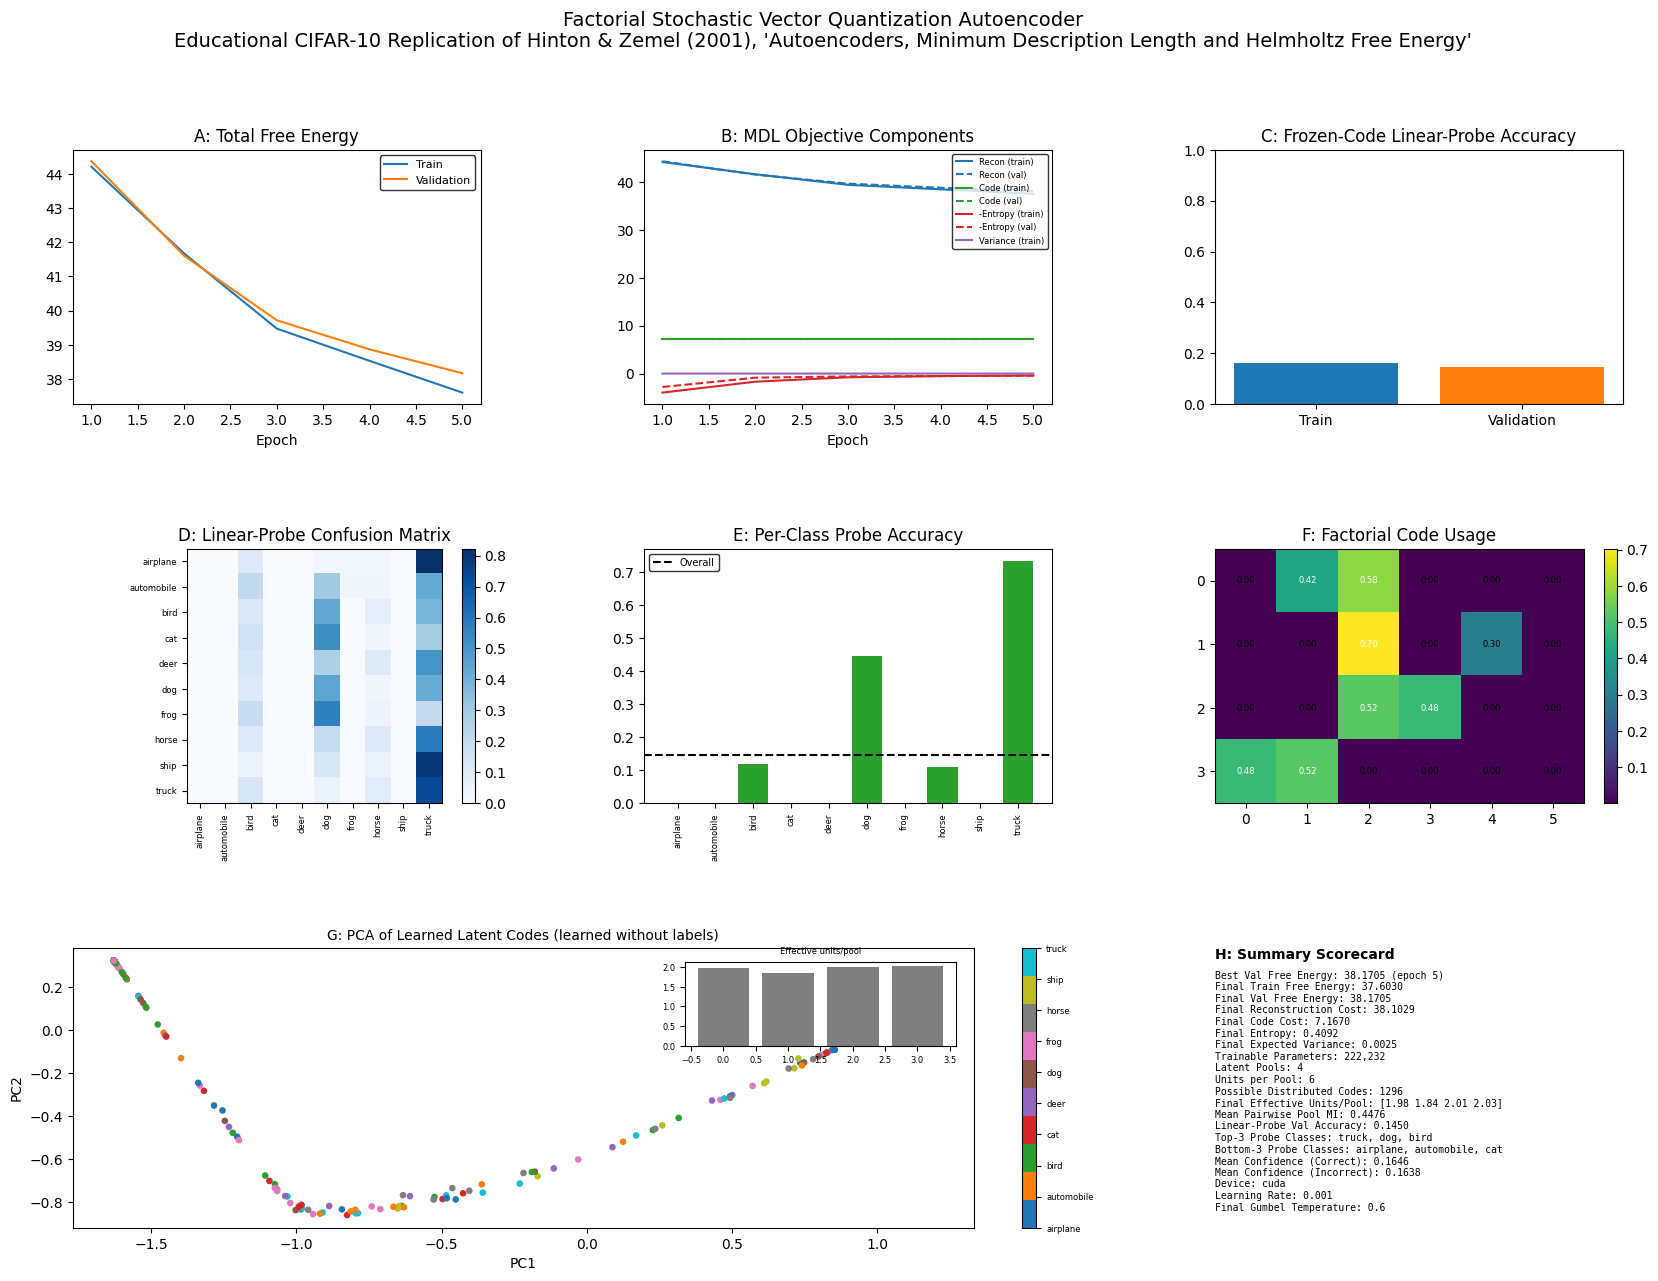

In [20]:
# ---------------------------------------------------------------------------------
# 18. FINAL DASHBOARD (publication-style, GridSpec, 8 panels A-H, three rows)
# ---------------------------------------------------------------------------------
set_white_theme()

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.1], hspace=0.55, wspace=0.4)

fig.suptitle(
    "Factorial Stochastic Vector Quantization Autoencoder\n"
    "Educational CIFAR-10 Replication of Hinton & Zemel (2001), "
    "'Autoencoders, Minimum Description Length and Helmholtz Free Energy'",
    fontsize=14, color="black"
)

# Panel A — Total Free Energy
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_free_energy"], label="Train", color="tab:blue")
axA.plot(epochs_range, history["val_free_energy"], label="Validation", color="tab:orange")
axA.set_title("A: Total Free Energy")
axA.set_xlabel("Epoch")
axA.legend(fontsize=8)

# Panel B — MDL Objective Components
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["train_recon_cost"], label="Recon (train)", color="tab:blue")
axB.plot(epochs_range, history["val_recon_cost"], label="Recon (val)", color="tab:blue", linestyle="--")
axB.plot(epochs_range, history["train_code_cost"], label="Code (train)", color="tab:green")
axB.plot(epochs_range, history["val_code_cost"], label="Code (val)", color="tab:green", linestyle="--")
neg_entropy_train = [-e for e in history["train_entropy"]]
neg_entropy_val = [-e for e in history["val_entropy"]]
axB.plot(epochs_range, neg_entropy_train, label="-Entropy (train)", color="tab:red")
axB.plot(epochs_range, neg_entropy_val, label="-Entropy (val)", color="tab:red", linestyle="--")
axB.plot(epochs_range, history["train_variance"], label="Variance (train)", color="tab:purple")
axB.set_title("B: MDL Objective Components")
axB.set_xlabel("Epoch")
axB.legend(fontsize=6, loc="upper right")

# Panel C — Frozen Linear-Probe Performance
axC = fig.add_subplot(gs[0, 2])
axC.bar(["Train", "Validation"], [probe_train_acc, probe_test_acc], color=["tab:blue", "tab:orange"])
axC.set_ylim(0, 1)
axC.set_title("C: Frozen-Code Linear-Probe Accuracy")

# Panel D — Confusion Matrix
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(conf_matrix_norm, cmap="Blues")
axD.set_xticks(range(10))
axD.set_yticks(range(10))
axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticklabels(class_names, fontsize=6)
axD.set_title("D: Linear-Probe Confusion Matrix")
plt.colorbar(imD, ax=axD, fraction=0.046)

# Panel E — Per-Class Probe Accuracy
axE = fig.add_subplot(gs[1, 1])
axE.bar(range(10), per_class_accuracy, color="tab:green")
axE.axhline(probe_test_acc, color="black", linestyle="--", label="Overall")
axE.set_xticks(range(10))
axE.set_xticklabels(class_names, rotation=90, fontsize=6)
axE.set_title("E: Per-Class Probe Accuracy")
axE.legend(fontsize=7)

# Panel F — Factorial Code Usage
axF = fig.add_subplot(gs[1, 2])
imF = axF.imshow(code_usage_heatmap, cmap="viridis", aspect="auto")
axF.set_xticks(range(UNITS_PER_POOL))
axF.set_yticks(range(NUM_POOLS))
axF.set_title("F: Factorial Code Usage")
for v in range(NUM_POOLS):
    for u in range(UNITS_PER_POOL):
        axF.text(u, v, f"{code_usage_heatmap[v, u]:.2f}", ha="center", va="center",
                  color="white" if code_usage_heatmap[v, u] > code_usage_heatmap.max() / 2 else "black",
                  fontsize=6)
plt.colorbar(imF, ax=axF, fraction=0.046)

# Panel G — Learned Latent Representation (PCA), large panel with inset
axG = fig.add_subplot(gs[2, 0:2])
scatterG = axG.scatter(pca_coords[:, 0], pca_coords[:, 1], c=test_labels_np, cmap="tab10", s=14)
axG.set_title("G: PCA of Learned Latent Codes (learned without labels)", fontsize=10)
axG.set_xlabel("PC1")
axG.set_ylabel("PC2")
cbar = plt.colorbar(scatterG, ax=axG, ticks=range(10), fraction=0.03)
cbar.ax.set_yticklabels(class_names, fontsize=6)

inset_ax = axG.inset_axes([0.68, 0.65, 0.3, 0.3])
inset_ax.bar(range(NUM_POOLS), final_eff_units, color="tab:gray")
inset_ax.set_title("Effective units/pool", fontsize=6)
inset_ax.tick_params(axis="both", labelsize=6)

# Panel H — Summary Scorecard
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

best_epoch_idx = int(np.argmin(history["val_free_energy"]))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

if len(per_class_accuracy) >= 3:
    top3_idx = np.argsort(per_class_accuracy)[::-1][:3]
    bottom3_idx = np.argsort(per_class_accuracy)[:3]
    top3_names = ", ".join([class_names[i] for i in top3_idx])
    bottom3_names = ", ".join([class_names[i] for i in bottom3_idx])
else:
    top3_names = "N/A"
    bottom3_names = "N/A"

mean_pairwise_mi = float(np.mean(final_mi_matrix[~np.eye(NUM_POOLS, dtype=bool)])) if NUM_POOLS > 1 else float("nan")

scorecard_lines = [
    f"Best Val Free Energy: {min(history['val_free_energy']):.4f} (epoch {best_epoch_idx+1})",
    f"Final Train Free Energy: {history['train_free_energy'][-1]:.4f}",
    f"Final Val Free Energy: {history['val_free_energy'][-1]:.4f}",
    f"Final Reconstruction Cost: {history['val_recon_cost'][-1]:.4f}",
    f"Final Code Cost: {history['val_code_cost'][-1]:.4f}",
    f"Final Entropy: {history['val_entropy'][-1]:.4f}",
    f"Final Expected Variance: {history['val_variance'][-1]:.4f}",
    f"Trainable Parameters: {total_params:,}",
    f"Latent Pools: {NUM_POOLS}",
    f"Units per Pool: {UNITS_PER_POOL}",
    f"Possible Distributed Codes: {NUM_POSSIBLE_CODES}",
    f"Final Effective Units/Pool: {np.array2string(final_eff_units, precision=2)}",
    f"Mean Pairwise Pool MI: {mean_pairwise_mi:.4f}",
    f"Linear-Probe Val Accuracy: {probe_test_acc:.4f}",
    f"Top-3 Probe Classes: {top3_names}",
    f"Bottom-3 Probe Classes: {bottom3_names}",
    f"Mean Confidence (Correct): {mean_conf_correct:.4f}" if not math.isnan(mean_conf_correct) else "Mean Confidence (Correct): N/A",
    f"Mean Confidence (Incorrect): {mean_conf_incorrect:.4f}" if not math.isnan(mean_conf_incorrect) else "Mean Confidence (Incorrect): N/A",
    f"Device: {device.type}",
    f"Learning Rate: {LEARNING_RATE}",
    f"Final Gumbel Temperature: {FINAL_TEMPERATURE}",
]

axH.text(0.0, 1.0, "H: Summary Scorecard", fontsize=10, fontweight="bold", va="top", ha="left", transform=axH.transAxes)
axH.text(
    0.0, 0.92, "\n".join(scorecard_lines),
    fontsize=7, va="top", ha="left", transform=axH.transAxes, family="monospace"
)

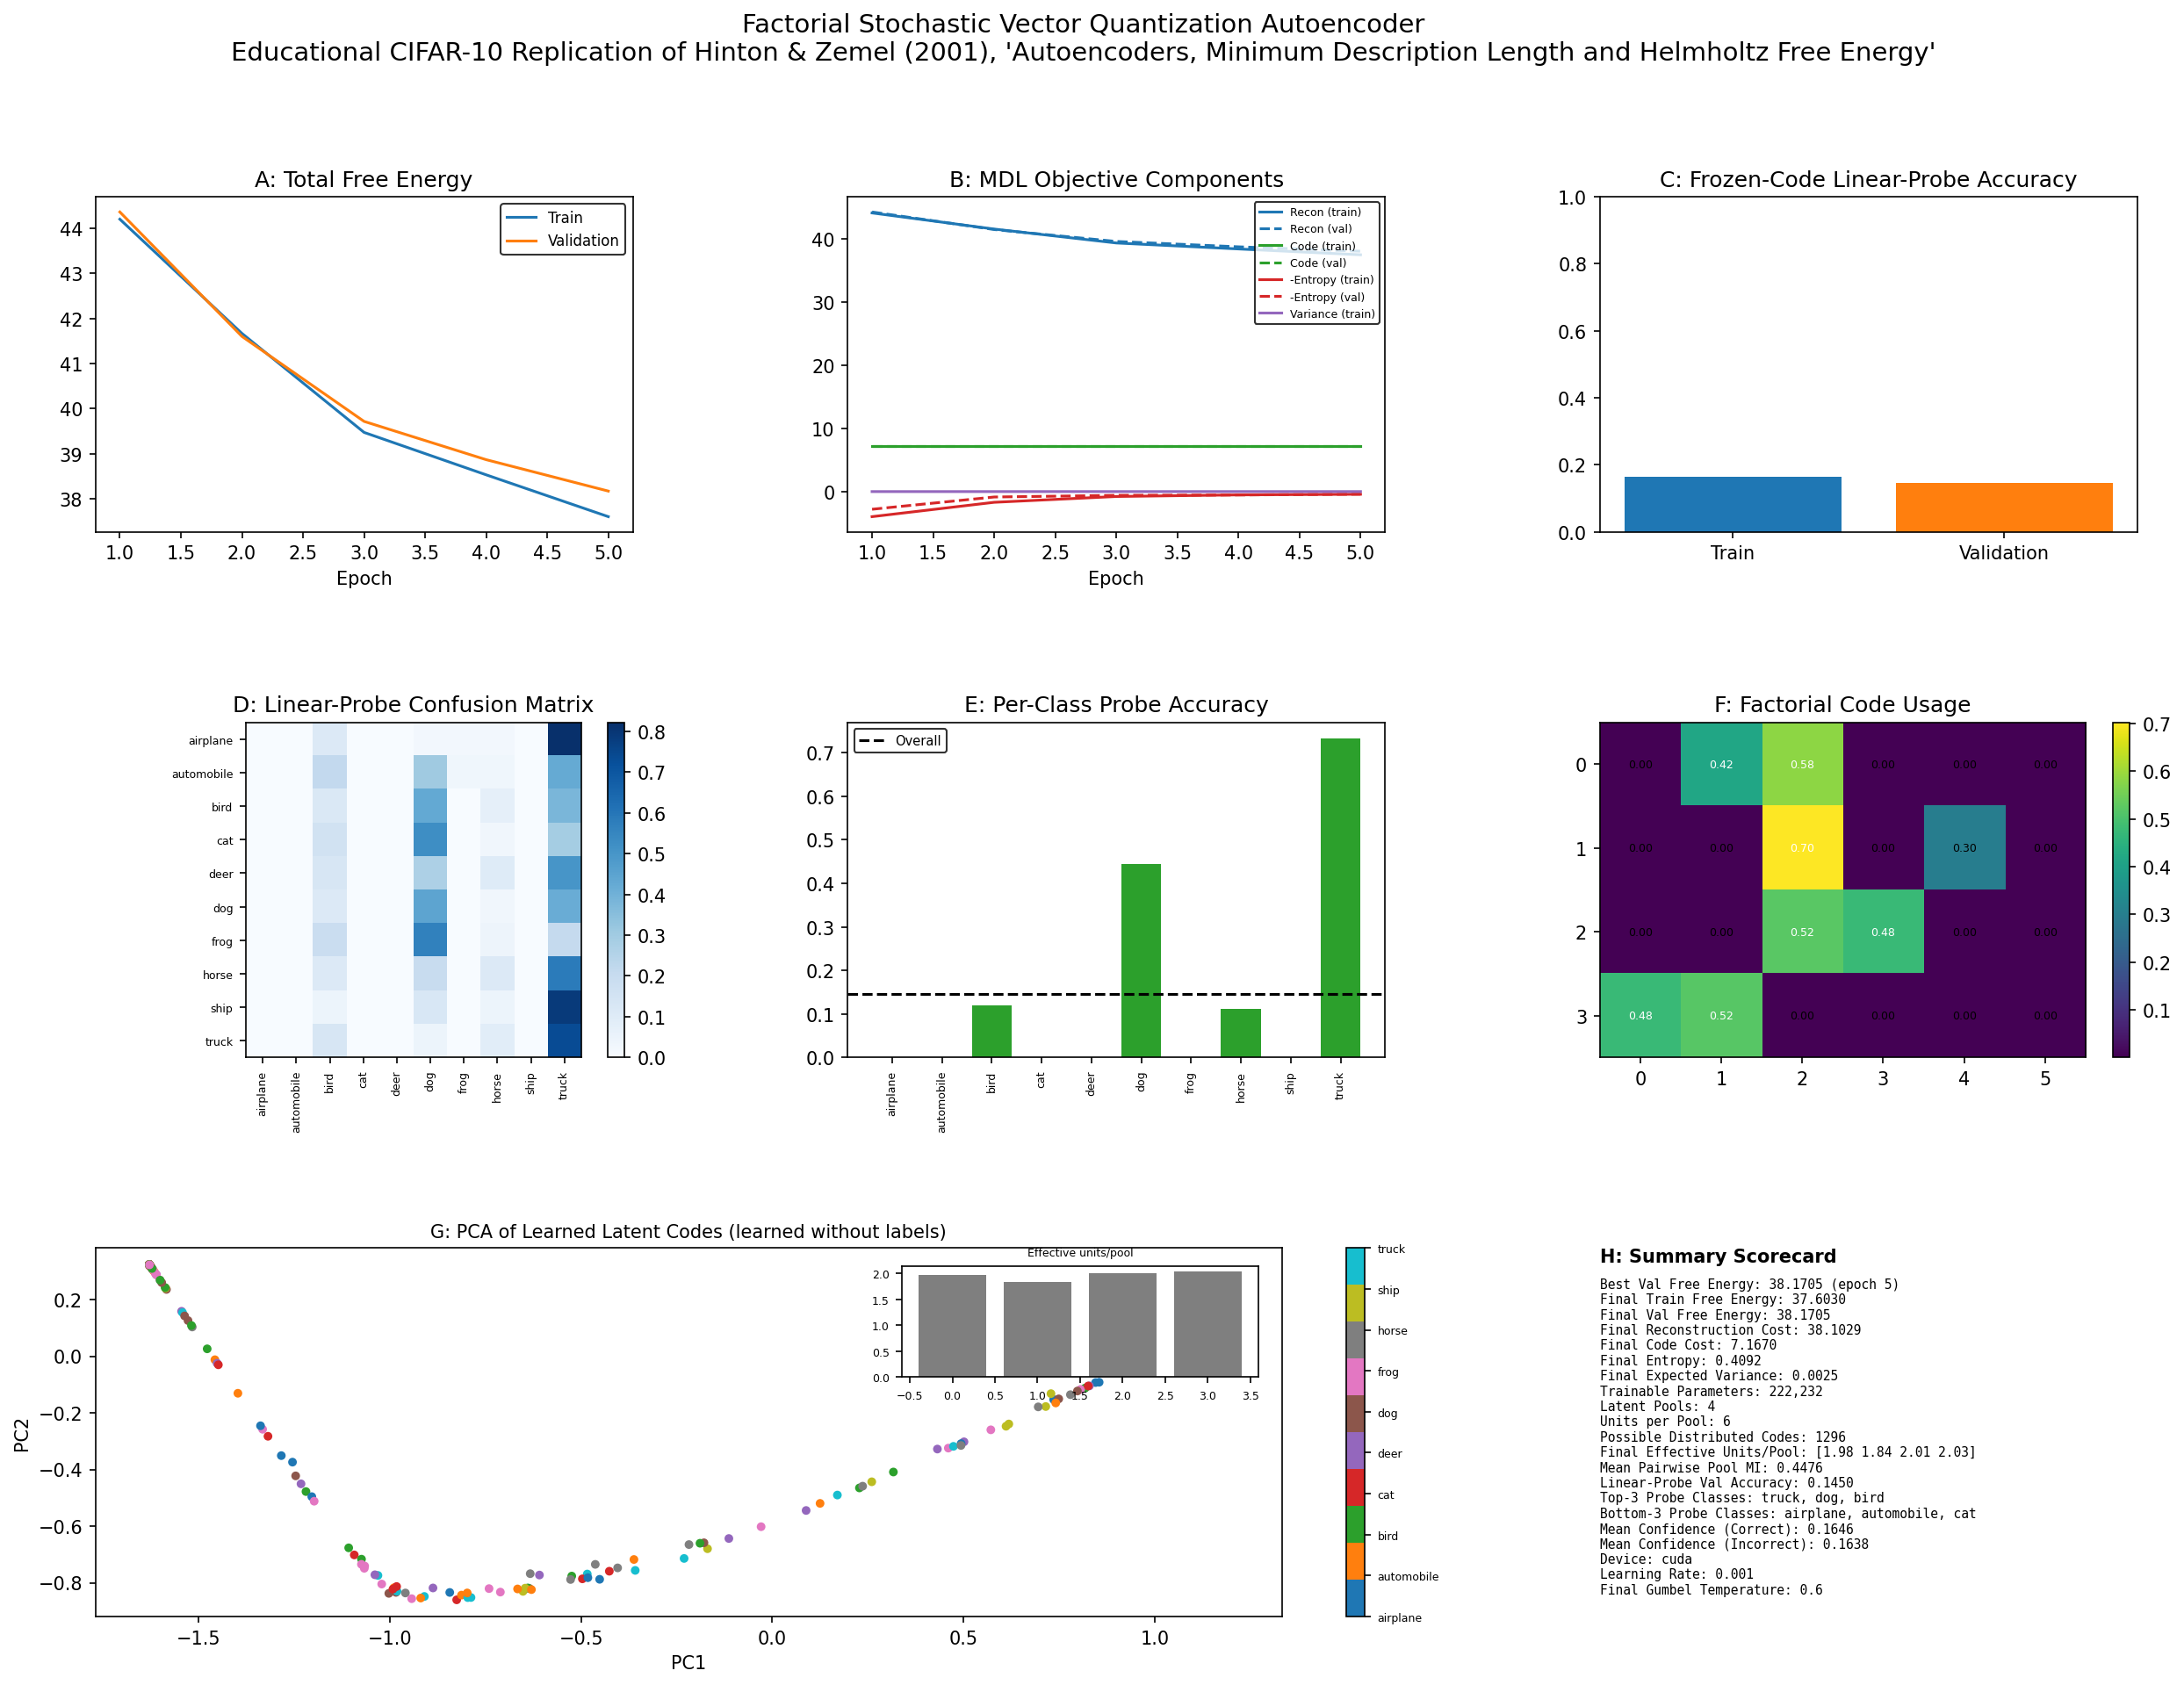

In [21]:
# ---------------------------------------------------------------------------------
# 19. DISPLAY DASHBOARD INLINE (no disk save, no plt.show())
# ---------------------------------------------------------------------------------
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Experimental Results Analysis: Factorial Stochastic VQ Autoencoder Dashboard

## 1. Total Free Energy (Panel A)

### Overview
Tracks the primary MDL-inspired training objective — the Helmholtz free energy $$F$$ — across training and validation sets over 5 epochs, evaluating whether the unsupervised optimization is converging.

### Key Findings
- Both training and validation free energy decrease monotonically from approximately 44.3 to 37.6 (train) and 38.2 (validation).
- The two curves track closely with a small, stable gap, train ending slightly below validation.
- The steepest decline occurs in epochs 1–2, with a flatter, still-decreasing slope thereafter.

### Discussion
The steady decrease confirms that gradient descent is successfully minimizing the combined reconstruction–code–entropy objective, indicating the recognition and generative networks are jointly learning a more efficient coding scheme. The small train–validation gap suggests limited overfitting, unsurprising given only 5 epochs and a small (2,000-sample) training subset. This trend is consistent with the paper's claim that $$F$$ behaves as a valid Lyapunov function for learning, since it decreases smoothly rather than oscillating.

### Limitations
Only 5 epochs were run, so it is unclear whether the objective has converged or would continue improving with further training. The small dataset size limits generalizability of the observed trend to full-scale CIFAR-10.

---

## 2. MDL Objective Components (Panel B)

### Overview
Decomposes the free energy into its three constituent terms — reconstruction cost, code cost, and negative entropy — plus the expected-variance term, isolating which component drives overall improvement.

### Key Findings
- Reconstruction cost dominates the objective numerically (~44 → ~38) and accounts for nearly all of the free-energy reduction.
- Code cost remains essentially flat around 7.2 throughout training, train and validation curves overlapping almost exactly.
- Negative entropy stays small and near zero, slightly negative early on and converging toward ~0 by epoch 5.
- The variance term is negligible throughout (near 0).

### Discussion
The dominance of reconstruction cost indicates that the model's learning signal is driven almost entirely by pixel-level fidelity rather than by code-cost or entropy pressure, given the small weighting coefficients (CODE_WEIGHT=0.01, ENTROPY_WEIGHT=0.01) relative to reconstruction. The flat code cost suggests the prior-based penalty is not strongly shaping pool usage, while the near-zero entropy term implies the recognition network is converging toward relatively peaked (low-entropy) distributions rather than exploiting substantial "bits-back" savings. This is consistent with the low ENTROPY_WEIGHT chosen and suggests the bits-back mechanism, while implemented, plays a subordinate role in this configuration compared to the paper's original emphasis.

### Limitations
The relative weighting of the three terms was fixed a priori rather than tuned, making it difficult to assess whether a different balance (e.g., higher entropy weight) would better reveal the stochastic-coding benefits central to the paper's argument. The flatness of the code-cost curve may also reflect insufficient training rather than true convergence.

---

## 3. Frozen-Code Linear-Probe Accuracy (Panel C)

### Overview
Evaluates the class-discriminative content of the unsupervised latent codes using a linear classifier trained on frozen recognition probabilities, following standard representation-learning evaluation protocol.

### Key Findings
- Train accuracy ≈ 0.16; validation accuracy ≈ 0.145, both far above chance-level for balanced 10-class classification (0.10) but far below competitive representation-learning benchmarks.
- Train and validation accuracies are close, indicating no meaningful overfitting.

### Discussion
The modest but above-chance accuracy indicates that the learned factorial codes contain some class-relevant structure, consistent with the model discovering low-level visual regularities (e.g., color/texture patterns) correlated with object categories. However, the small margin over chance reflects the limited capacity of the representation (4 pools × 6 units = 24-dimensional one-hot-like probability vector), the small training set, low input resolution (16×16), and only 5 training epochs — all of which constrain representational richness compared to deep convolutional or contrastive methods.

### Limitations
The extremely small latent dimensionality and shallow, fully-connected architecture (no convolutional structure) fundamentally limit representational capacity; this result should not be interpreted as a strong test of the free-energy objective's representational quality, but rather as a sanity check that the codes are non-degenerate.

---

## 4. Linear-Probe Confusion Matrix (Panel D)

### Overview
Shows per-class prediction patterns of the frozen-code linear probe, revealing which classes are confused with one another.

### Key Findings
- Strong diagonal-off bias: nearly all classes are frequently misclassified as "truck," with "truck" receiving high predicted-probability mass across almost every true class row.
- Some genuine structure exists for "dog," "frog," and "bird," which show partial self-classification and cross-confusion with each other.
- Classes such as "airplane," "automobile," "deer," and "ship" show near-zero correct classification.

### Discussion
The systematic bias toward predicting "truck" suggests the linear probe (and underlying latent space) has collapsed toward a dominant mode, likely because the factorial codes do not yet separate classes well and the probe defaults to the majority-favorable direction in a low-information latent space. The partial success on animal classes (dog, frog, bird) may reflect shared low-level texture/color statistics captured by the pooled 16×16 representation. This pattern indicates the representation is only weakly discriminative and dominated by a small number of principal variation modes, consistent with the compressed PCA trajectory observed in Panel G.

### Limitations
With only 400 test samples spread across 10 classes, per-class statistics are noisy (≈40 samples/class), and the confusion matrix may not reliably reflect systematic class relationships versus small-sample artifacts.

---

## 5. Per-Class Probe Accuracy (Panel E)

### Overview
Quantifies classification accuracy separately for each CIFAR-10 category, identifying which classes benefit most from the learned representation.

### Key Findings
- "Truck" achieves the highest per-class accuracy (~0.73), substantially above the overall average (~0.145, dashed line).
- "Dog" (~0.45) and "horse"/"bird" (~0.11–0.12) show moderate accuracy.
- Six of ten classes ("airplane," "automobile," "cat," "deer," "frog," "ship") show zero or near-zero accuracy.

### Discussion
The heavy skew toward "truck" corroborates the confusion-matrix finding: the classifier is effectively defaulting to a dominant class for most inputs, artificially inflating truck accuracy while collapsing others to zero. This is a classic symptom of class imbalance in decision boundaries induced by an uninformative or collapsed feature space, rather than a genuine categorical understanding. It suggests that, at this training budget, the factorial VQ codes have not yet developed sufficiently distinct per-class manifolds to support balanced linear separability.

### Limitations
The reported accuracies are sensitive to the small test set and to the linear probe's convergence within `max_iter=2000`; results might shift with more balanced regularization (e.g., class-weighted logistic regression) or longer autoencoder training.

---

## 6. Factorial Code Usage (Panel F)

### Overview
Visualizes the average recognition probability assigned to each unit within each of the four latent pools, assessing whether pools use their full capacity (all 6 alternatives) or collapse to a subset.

### Key Findings
- Pool 0: usage concentrated on units 1–2 (0.42, 0.58); units 0, 3–5 unused.
- Pool 1: usage split between units 2 and 4 (0.70, 0.30); other units unused.
- Pool 2: usage split between units 2 and 3 (0.52, 0.48).
- Pool 3: usage split between units 0 and 1 (0.48, 0.52).
- In every pool, only 2 of 6 available units carry non-negligible probability mass.

### Discussion
This pattern reveals a form of representational collapse: rather than utilizing all 6 categorical alternatives per pool, the recognition network effectively behaves as a binary switch within each pool. This is corroborated by the "Final Effective Units/Pool" metric in the scorecard (~1.84–2.03 out of 6 possible), confirming quantitatively that only about 2 alternatives are meaningfully used per pool. This likely results from the code-cost term (uniform prior penalty) combined with limited training discouraging exploration of additional alternatives, and/or the Gumbel-Softmax temperature schedule (1.0→0.6) not being low enough or training long enough to sharpen and diversify pool usage. This under-utilization limits the effective code space to roughly $$2^4 = 16$$ combinations rather than the theoretical 1,296, substantially constraining representational capacity and helping explain the weak linear-probe performance.

### Limitations
Whether this collapse is a fundamental limitation of the objective or an artifact of the short 5-epoch training schedule and small dataset cannot be disambiguated from this experiment alone; longer training or entropy-weight tuning could plausibly increase effective pool utilization.

---

## 7. PCA of Learned Latent Codes (Panel G)

### Overview
Projects the 24-dimensional flattened recognition-probability vectors into two principal components, colored by true CIFAR-10 class, to visually assess cluster structure and class separability in the unsupervised embedding space.

### Key Findings
- Points from all classes collapse onto a narrow, curved one-dimensional manifold rather than forming distinct clusters.
- No visually separable class clusters are apparent; colors are heavily intermixed along the trajectory.
- The inset shows effective active units per pool ranging from approximately 1.84 to 2.03 (out of 6), consistent with Panel F's collapse finding.

### Discussion
The absence of class-separated clusters in PCA space directly explains the low linear-probe accuracy: the learned representation appears to encode a small number of continuous or ordinal factors (evidenced by the smooth curve-like manifold) rather than discrete, class-correlated categories. This is consistent with the restricted effective pool usage (~2 units/pool), which limits the representation to a low-dimensional discrete code space insufficient for capturing the visual diversity of 10 object categories. The curved, low-dimensional embedding pattern is reminiscent of the original paper's spline dataset, where FVQ pools captured smooth, low-dimensional generative factors — suggesting the model is behaving as designed but the underlying CIFAR-10 statistics (natural image variability) are far more complex than the paper's synthetic spline images.

### Limitations
Two-dimensional PCA projection may obscure higher-dimensional structure present in the 24-dimensional latent space; higher-variance principal components or nonlinear embeddings (e.g., t-SNE) might reveal additional structure not visible here.

---

## 8. Summary Scorecard (Panel H)

### Overview
Consolidates final-epoch metrics, architectural configuration, and probe results into a single reference table for holistic model assessment.

### Key Findings
- Final free energy: 37.60 (train) / 38.17 (validation); reconstruction cost dominates (38.10) with code cost 7.17 and entropy 0.41.
- Mean pairwise pool mutual information: 0.4476 — non-trivial, indicating pools are not fully independent.
- Linear-probe validation accuracy: 0.1450; near-identical mean confidence for correct (0.1646) and incorrect (0.1638) predictions.
- Effective units per pool: 1.98–2.03 out of 6, confirming substantial under-utilization of code capacity.
- 222,232 trainable parameters trained for 5 epochs at learning rate 0.001.

### Discussion
The near-identical confidence between correct and incorrect predictions indicates the linear probe is poorly calibrated and not confidently discriminating between classes — consistent with a representation lacking strong class structure. The moderate mutual information (0.4476) between nominally independent pools suggests the factorial assumption is only partially satisfied in practice: pools are not perfectly independent, meaning the true joint posterior deviates from the tractable factorial approximation, exactly the scenario the paper anticipates and explains via the KL-divergence "excess bits" argument. Overall, the scorecard supports the qualitative claim that the free-energy objective drives coherent, monotonic optimization (Panel A/B) and produces structured, if functionally redundant, factorial codes (Panels F/G), but the small-scale training regime is insufficient to yield semantically rich or highly discriminative representations comparable to the original paper's clean spline-image results.

### Limitations
The single-run, 5-epoch, 2,000-sample setup is a deliberately minimal educational configuration; the reported metrics should be interpreted as demonstrating correct implementation of the paper's mechanisms rather than as a competitive benchmark of representation quality. No statistical variance (e.g., multiple seeds) is reported, limiting confidence in the precision of the quantitative values.

# Related Work Referenced in This Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Baldi, P. and Hornik, K. | 1989 | Neural networks and principal components analysis: Learning from examples without local minima | Neural Networks, 2, 53–58 | Establishes that PCA can be implemented within the autoencoder framework, providing the basis for treating PCA as a special (linear) case of the paper's general MDL-based autoencoder objective |
| Galland, C. C. | 1993 | The limitations of deterministic Boltzmann machine learning | Network, 4, 355–379 | Provides justification for the paper's use of mean-field-style factorial approximations, showing that non-independence among units leads to an overestimate of description length rather than a failure of the learning method |
| Hinton, G. E. | 1989 | Connectionist learning procedures | Artificial Intelligence, 40, 185–234 | Cited alongside Baldi and Hornik (1989) as prior work situating PCA and VQ within the autoencoder framework, motivating the paper's unification of these methods under one objective |
| Neal, R. and Hinton, G. E. | 1993 | A new view of the EM algorithm that justifies incremental and other variants | Manuscript (unpublished) | Introduces the use of non-equilibrium free energy as a Lyapunov function for learning, which is the direct theoretical basis for the paper's use of $$F$$ to guide gradient-based learning even when the approximate distribution is suboptimal |
| Rissanen, J. | 1989 | Stochastic Complexity in Statistical Inquiry | World Scientific Publishing Co., Singapore | Source of the Minimum Description Length (MDL) principle and the concept of stochastic complexity, forming the core theoretical framework the paper builds its autoencoder objective upon |
| Zemel, R. S. | 1993 | A Minimum Description Length Framework for Unsupervised Learning | PhD Thesis, University of Toronto | Provides the datasets (e.g., the spline dataset) and prior development of MDL-based unsupervised learning that the current paper's experiments and framework directly extend |
| Zemel, R. S. and Hinton, G. E. | 1994 | Developing Population Codes by Minimizing Description Length | In Advances in Neural Information Processing Systems 6, Morgan Kaufmann | Described as related/follow-up work applying the same MDL/free-energy approach to population codes, indicating the broader applicability of the framework proposed in this paper |